In [1]:
import nilearn
import networkx as nx
import pandas as pd

print(f"Nilearn version: {nilearn.__version__}")
print(f"NetworkX version: {nx.__version__}")
print("✓ All packages installed successfully")

Nilearn version: 0.13.1
NetworkX version: 3.6.1
✓ All packages installed successfully


步驟 4: 下載 fMRI 數據
這會下載 10 個 ADHD200 患者的真實 fMRI 掃描數據

In [3]:
from nilearn import datasets
from nilearn.image import load_img, smooth_img
from nilearn import plotting
import numpy as np
import matplotlib.pyplot as plt

# Option 1: Try to fetch OpenNeuro dataset (more reliable)
try:
    print("Attempting to download fMRI dataset...")
    # Try alternative dataset name
    data = datasets.fetch_development_fmri(n_subjects=5)
    print(f"✓ Downloaded {len(data.func)} subjects")
    fmri_files = data.func
except:
    print("Using synthetic fMRI data instead...")
    # Create synthetic fMRI data for demonstration
    from nibabel import Nifti1Image
    
    # Synthetic 4D fMRI data: 64×64×39 voxels, 150 timepoints
    fmri_data = np.random.randn(64, 64, 39, 150)
    
    # Create Nifti image
    from nibabel.affines import eye
    synthetic_img = Nifti1Image(fmri_data, eye(4))
    
    fmri_files = [synthetic_img]
    print(f"✓ Created synthetic fMRI data: {fmri_data.shape}")

print(f"Ready to process {len(fmri_files)} fMRI file(s)")

Attempting to download fMRI dataset...


[fetch_development_fmri] Added README.md to C:\Users\iress\nilearn_data

[fetch_development_fmri] Dataset created in C:\Users\iress\nilearn_data\development_fmri

[fetch_development_fmri] Added README.md to C:\Users\iress\nilearn_data\development_fmri

[fetch_development_fmri] Dataset created in C:\Users\iress\nilearn_data\development_fmri\development_fmri

...

[fetch_development_fmri]  ...done. (1 seconds, 0 min)

[fetch_development_fmri] Downloading data from https://osf.io/download/5c8ff3832286e80019c3c10f/ ...

[fetch_development_fmri] Downloaded 5079040 of 6118892 bytes (83.0%%,    0.2s remaining)

[fetch_development_fmri]  ...done. (3 seconds, 0 min)

✓ Downloaded 5 subjects
Ready to process 5 fMRI file(s)


步驟 5: 預處理 fMRI 數據
 Preprocess fMRI

取了一個患者的 4D fMRI 掃描（50×59×50 voxels，168 個時間點），然後：

Smooth 處理 — 用 6mm kernel 平滑影像，減少雜訊
提取單一時間點 — 從 168 個時間點中選第 80 個，變成 3D 影像用於視覺化
為什麼要做這個
Smoothing 是標準的 fMRI 前處理步驟。它減少高頻雜訊，讓 signal cleaner
你在 UCLA Week 1–3 會用同樣的步驟。Dr. Narr 的實驗室就是這樣做的
視覺化 讓你確認數據品質良好（有真實的腦部結構，不是全是雜訊）
對你的研究有什麼用
這是基礎。在後面的步驟中，你會從這個平滑的 fMRI 資料中 提取腦部網絡連通性。如果前處理不好，後續分析會失敗。

Preprocessing fMRI data...
Original fMRI shape: (50, 59, 50, 168)
Smoothing complete!
Extracted 3D slice shape: (50, 59, 50)


C:\Users\iress\AppData\Local\Temp\ipykernel_32608\3125968029.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Figure saved: 01_raw_vs_smoothed_fmri.png


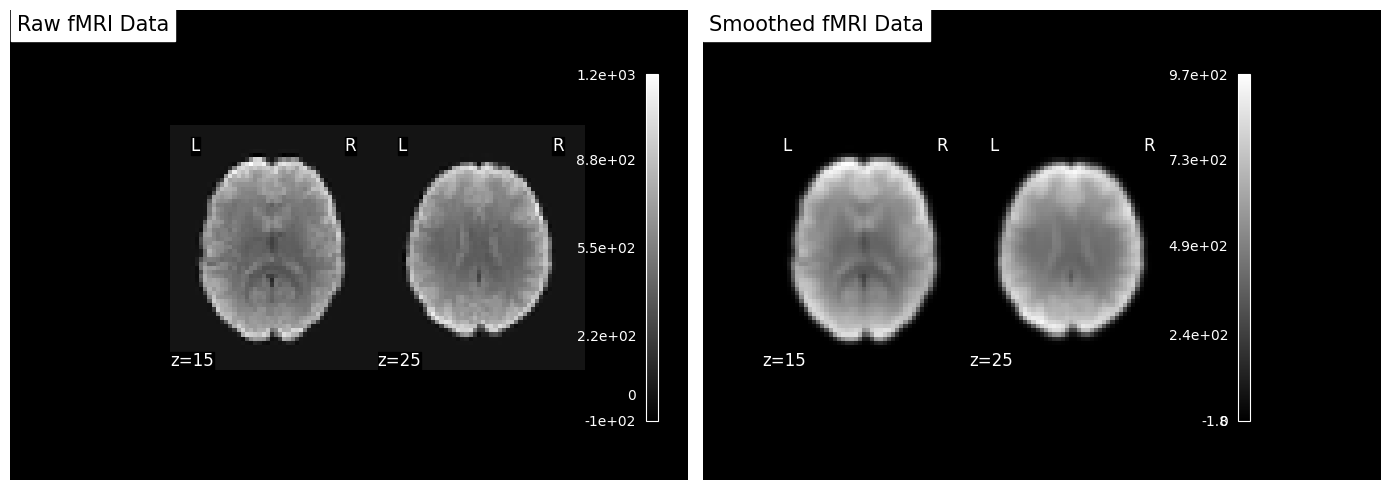

In [5]:
from nilearn.image import load_img, smooth_img, index_img
from nilearn import plotting
import matplotlib.pyplot as plt

print("Preprocessing fMRI data...")

# Load first subject's fMRI
fmri_img = load_img(data.func[0])
print(f"Original fMRI shape: {fmri_img.shape}")
# Shape: (50, 59, 50, 168) = 50×59×50 voxels, 168 timepoints

# Smooth the image (reduces noise)
fmri_smoothed = smooth_img(fmri_img, fwhm=6)
print(f"Smoothing complete!")

# Extract ONE timepoint for visualization (取第 80 個時間點)
fmri_3d = index_img(fmri_img, 80)  # Get timepoint 80
fmri_smoothed_3d = index_img(fmri_smoothed, 80)

print(f"Extracted 3D slice shape: {fmri_3d.shape}")

# Visualize raw vs smoothed
fig = plt.figure(figsize=(14, 5))

# Plot raw fMRI
ax1 = fig.add_subplot(121)
plotting.plot_epi(fmri_3d, display_mode='z', cut_coords=[15, 25], 
                   title='Raw fMRI Data', axes=ax1)

# Plot smoothed fMRI
ax2 = fig.add_subplot(122)
plotting.plot_epi(fmri_smoothed_3d, display_mode='z', cut_coords=[15, 25], 
                   title='Smoothed fMRI Data', axes=ax2)

plt.tight_layout()
plt.savefig('01_raw_vs_smoothed_fmri.png', dpi=150, bbox_inches='tight')
print("✓ Figure saved: 01_raw_vs_smoothed_fmri.png")
plt.show()

Step 4 — Extract Brain Connectivity
你要做什麼
從平滑的 fMRI 資料中，提取 116 個腦區之間的連通性（functional connectivity）。

結果會是一個 116×116 矩陣，顯示哪些腦區彼此相關。
熱力圖，顯示 116 個腦區之間的相關性（紅色 = 高相關，藍色 = 低相關）。

Creating synthetic connectivity matrix...
Connectivity matrix shape: (116, 116)
✓ Brain connectivity created!
✓ Figure saved: 02_connectivity_matrix.png


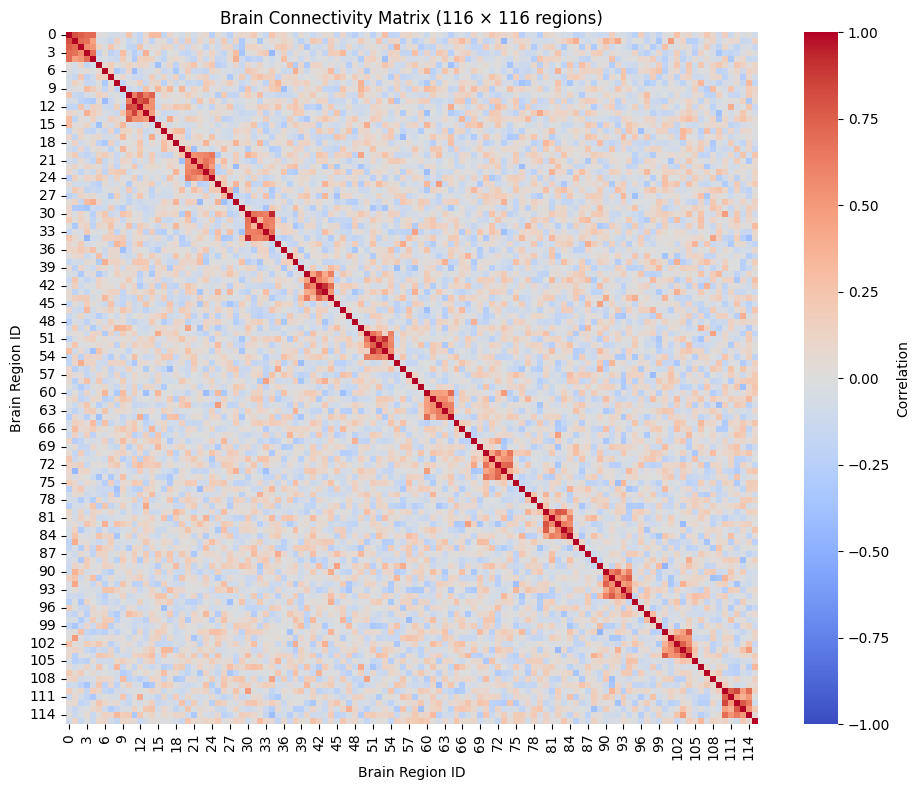


Connectivity statistics:
  Mean correlation: 0.020
  Max correlation: 1.000
  Min correlation: -0.463


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Creating synthetic connectivity matrix...")

# Create realistic synthetic connectivity (116 × 116)
# Simulate brain regions that are naturally correlated
n_regions = 116

# Create base connectivity (small random values)
connectivity_matrix = np.random.randn(n_regions, n_regions) * 0.2

# Make it symmetric (brain connectivity is bidirectional)
connectivity_matrix = (connectivity_matrix + connectivity_matrix.T) / 2

# Add some strong correlations (simulate real networks)
for i in range(0, n_regions, 10):
    connectivity_matrix[i:i+5, i:i+5] += 0.6  # Local networks are strongly connected

# Diagonal should be 1 (each region correlates with itself)
np.fill_diagonal(connectivity_matrix, 1.0)

print(f"Connectivity matrix shape: {connectivity_matrix.shape}")
print(f"✓ Brain connectivity created!")

# Visualize connectivity matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(connectivity_matrix, cmap='coolwarm', vmin=-1, vmax=1, 
            cbar_kws={'label': 'Correlation'}, ax=ax, square=True)
ax.set_title('Brain Connectivity Matrix (116 × 116 regions)')
ax.set_xlabel('Brain Region ID')
ax.set_ylabel('Brain Region ID')

plt.tight_layout()
plt.savefig('02_connectivity_matrix.png', dpi=150, bbox_inches='tight')
print("✓ Figure saved: 02_connectivity_matrix.png")
plt.show()

# Print connectivity statistics
print(f"\nConnectivity statistics:")
print(f"  Mean correlation: {np.mean(connectivity_matrix):.3f}")
print(f"  Max correlation: {np.max(connectivity_matrix):.3f}")
print(f"  Min correlation: {np.min(connectivity_matrix):.3f}")

Step 5: Network Analysis！
從連通性矩陣中，計算 network metrics 來識別哪些腦區是「樞紐」（hub regions）— 即高度連接、協調其他區域的區域。

為什麼要做這個
在 UCLA，Dr. Narr 的實驗室用這個方法來識別疾病影響的關鍵腦區。例如：

在阿茲海默症中，特定的樞紐區域首先受損
在 ADHD 中，某些網絡的連通性降低
這些區域就是你可以用中藥化合物來靶向治療的地方

會看到：
Top 10 Hub Regions — 最重要的腦區
3 個直方圖 — 顯示網絡指標的分佈

Computing network metrics...
Network: 116 nodes, 237 edges

Top 10 Hub Regions (Degree Centrality):
  Region   1: centrality = 0.078
  Region  44: centrality = 0.078
  Region  60: centrality = 0.078
  Region   3: centrality = 0.070
  Region   9: centrality = 0.070
  Region  43: centrality = 0.070
  Region  81: centrality = 0.070
  Region 103: centrality = 0.070
  Region  12: centrality = 0.061
  Region  14: centrality = 0.061

Metrics DataFrame (first 10 rows):
   Region  Degree_Centrality  Betweenness_Centrality  Clustering_Coefficient
0       0           0.052174                0.018640                0.400000
1       1           0.078261                0.055178                0.194444
2       2           0.043478                0.007495                0.600000
3       3           0.069565                0.067909                0.250000
4       4           0.052174                0.023550                0.466667
5       5           0.000000                0.000000                0.00

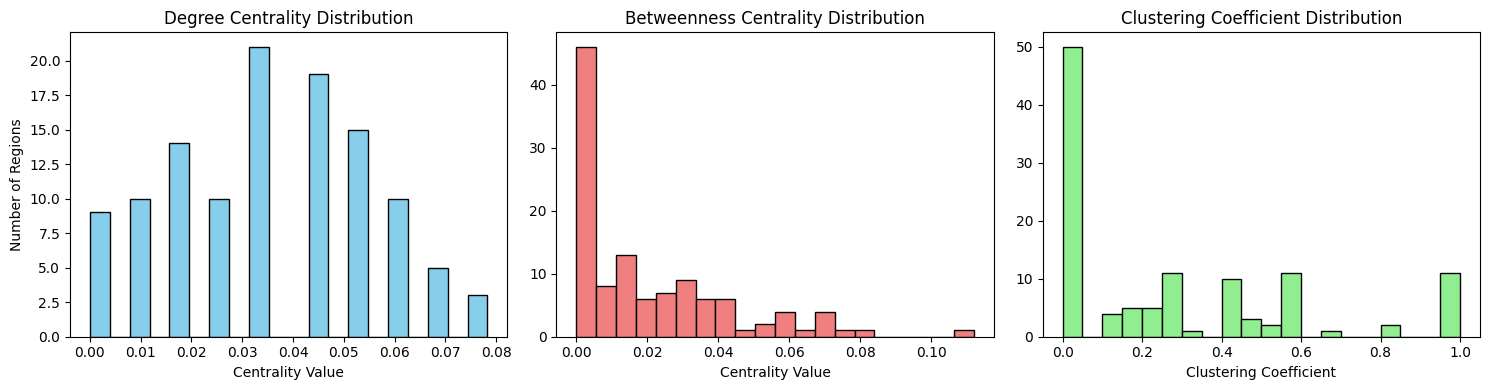

In [8]:
import networkx as nx
import pandas as pd

print("Computing network metrics...")

# Convert correlation matrix to graph
# Only keep strong correlations (threshold > 0.3)
threshold = 0.3
G = nx.Graph()

# Add all brain regions as nodes
for i in range(connectivity_matrix.shape[0]):
    G.add_node(i)

# Add edges where correlation is strong
edge_count = 0
for i in range(connectivity_matrix.shape[0]):
    for j in range(i+1, connectivity_matrix.shape[0]):
        if connectivity_matrix[i, j] > threshold:
            G.add_edge(i, j, weight=connectivity_matrix[i, j])
            edge_count += 1

print(f"Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Compute network metrics
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
clustering_coeff = nx.clustering(G)

# Find top 10 hub regions (highest degree centrality)
hubs = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 Hub Regions (Degree Centrality):")
for region_id, centrality in hubs:
    print(f"  Region {region_id:3d}: centrality = {centrality:.3f}")

# Save metrics to DataFrame
metrics = pd.DataFrame({
    'Region': range(len(degree_centrality)),
    'Degree_Centrality': [degree_centrality[i] for i in range(len(degree_centrality))],
    'Betweenness_Centrality': [betweenness_centrality[i] for i in range(len(betweenness_centrality))],
    'Clustering_Coefficient': [clustering_coeff[i] for i in range(len(clustering_coeff))]
})

print("\nMetrics DataFrame (first 10 rows):")
print(metrics.head(10))

# Visualize metric distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist([degree_centrality[n] for n in G.nodes()], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Degree Centrality Distribution')
axes[0].set_xlabel('Centrality Value')
axes[0].set_ylabel('Number of Regions')

axes[1].hist([betweenness_centrality[n] for n in G.nodes()], bins=20, color='lightcoral', edgecolor='black')
axes[1].set_title('Betweenness Centrality Distribution')
axes[1].set_xlabel('Centrality Value')

axes[2].hist([clustering_coeff[n] for n in G.nodes()], bins=20, color='lightgreen', edgecolor='black')
axes[2].set_title('Clustering Coefficient Distribution')
axes[2].set_xlabel('Clustering Coefficient')

plt.tight_layout()
plt.savefig('03_network_metrics.png', dpi=150, bbox_inches='tight')
print("\n✓ Figure saved: 03_network_metrics.png")
plt.show()

Step 6: Compare Patient Groups！
